In [1]:
import json
import logging
from utils.cross_validation_siamese_raw import (
    CrossValidationSiameseRaw, 
    TrainingProcedureParameters, 
    TrainingParameters
)
from utils.gait_parameters_extractor import CoordinatesIdx
from pathlib import Path


with open("./datasets/mocap/dataset_mocap_cycles_split.json", "r") as file:
    mocap_cycles = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_cycles_split.json", "r") as file:
    yolo_cycles = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_best_cameras_cycles_split.json", "r") as file:
    yolo_best_cams_cycles = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_cycles_split_butterworth.json", "r") as file:
    yolo_cycles_butterworth = json.load(file)

with open("./datasets/yolo/dataset_yolo26_triang_best_cameras_cycles_split_butterworth.json", "r") as file:
    yolo_best_cams_cycles_butterworth = json.load(file)

In [2]:
tpp = TrainingProcedureParameters(
    tp_conv1d = TrainingParameters(
        learning_rate = 1e-6,
        batch_size = 32,
        n_epochs = 100,
    ),
    tp_lstm = TrainingParameters(
        learning_rate = 1e-5,
        batch_size = 32,
        n_epochs = 150,
    )
)

tpp

TrainingProcedureParameters(tp_conv1d=TrainingParameters(learning_rate=1e-06, batch_size=32, n_epochs=100), tp_lstm=TrainingParameters(learning_rate=1e-05, batch_size=32, n_epochs=150), n_folds=4)

2026-02-09 00:06:12,436 - mocap - INFO - Preparing cycles and participant labels...
2026-02-09 00:06:27,356 - mocap - DEBUG - Participant 1 -> 10 samples
2026-02-09 00:06:27,358 - mocap - DEBUG - Participant 2 -> 12 samples
2026-02-09 00:06:27,358 - mocap - DEBUG - Participant 3 -> 12 samples
2026-02-09 00:06:27,359 - mocap - DEBUG - Participant 4 -> 8 samples
2026-02-09 00:06:27,360 - mocap - DEBUG - Participant 5 -> 12 samples
2026-02-09 00:06:27,360 - mocap - DEBUG - Participant 6 -> 11 samples
2026-02-09 00:06:27,361 - mocap - DEBUG - Participant 7 -> 11 samples
2026-02-09 00:06:27,361 - mocap - DEBUG - Participant 8 -> 9 samples
2026-02-09 00:06:27,362 - mocap - DEBUG - Participant 9 -> 10 samples
2026-02-09 00:06:27,362 - mocap - DEBUG - Participant 10 -> 12 samples
2026-02-09 00:06:27,363 - mocap - DEBUG - Participant 11 -> 10 samples
2026-02-09 00:06:27,363 - mocap - DEBUG - Participant 12 -> 11 samples
2026-02-09 00:06:27,364 - mocap - DEBUG - Participant 13 -> 9 samples
2026-

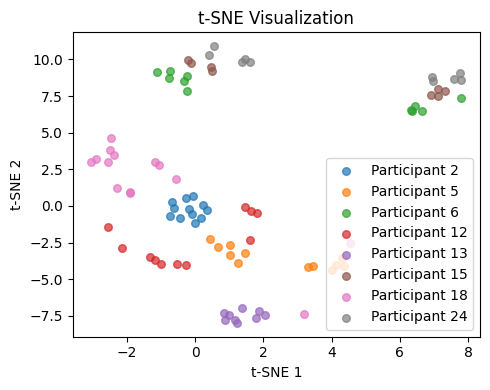

2026-02-09 00:08:05,723 - mocap - INFO - Test set size for rank classification: 87
2026-02-09 00:08:05,725 - mocap - INFO - Starting cross-validated model evaluation...
2026-02-09 00:08:05,725 - mocap - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:08:05,726 - mocap - INFO - -------------------------------------------------------
2026-02-09 00:08:05,749 - mocap - INFO - k-NN eucl    | 0.8059     | 0.9660     | 0.9771
2026-02-09 00:08:05,769 - mocap - INFO - k-NN manh    | 0.8170     | 0.9882     | 0.9882
2026-02-09 00:08:05,807 - mocap - INFO - SVM          | 0.9314     | 0.9660     | 0.9889
2026-02-09 00:08:06,742 - mocap - INFO - MLP          | 0.8967     | 0.9654     | 0.9771
2026-02-09 00:08:06,764 - mocap - INFO - NB           | 0.8739     | 0.9431     | 0.9771
2026-02-09 00:08:06,808 - mocap - INFO - LR           | 0.8967     | 0.9425     | 0.9882
2026-02-09 00:08:07,427 - mocap - INFO - RF           | 0.8614     | 0.9654     | 0.9765
2026-02-09 00:08:1

In [3]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = mocap_cycles, 
    coordinates_idx = CoordinatesIdx(2, 0, 1), 
    log_level = logging.DEBUG,
    logger_name = 'mocap',
    involve_hands_parameters = False,
)
cv.count_participants_samples()
cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "conv1d",
    learning_rate = tpp.tp_conv1d.learning_rate,
    batch_size = tpp.tp_conv1d.batch_size,
    n_epochs = tpp.tp_conv1d.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:08:11,210 - mocap - INFO - Preparing cycles and participant labels...
2026-02-09 00:08:25,899 - mocap - INFO - [Iteration 1/4]
2026-02-09 00:08:25,900 - mocap - INFO - [Iteration 2/4]
2026-02-09 00:08:25,942 - mocap - INFO - Train dataset size: 4452
2026-02-09 00:08:25,943 - mocap - INFO - Using device: cuda
2026-02-09 00:08:26,970 - mocap - INFO - Epoch 1, Train Loss: 0.3730148933827877
2026-02-09 00:08:27,911 - mocap - INFO - Epoch 2, Train Loss: 0.3554404615291527
2026-02-09 00:08:28,851 - mocap - INFO - Epoch 3, Train Loss: 0.34250234993440765
2026-02-09 00:08:29,772 - mocap - INFO - Epoch 4, Train Loss: 0.32084874074373926
2026-02-09 00:08:30,716 - mocap - INFO - Epoch 5, Train Loss: 0.30149456986359185
2026-02-09 00:08:31,669 - mocap - INFO - Epoch 6, Train Loss: 0.287963399716786
2026-02-09 00:08:32,587 - mocap - INFO - Epoch 7, Train Loss: 0.27336575729506357
2026-02-09 00:08:33,731 - mocap - INFO - Epoch 8, Train Loss: 0.25776036126273016
2026-02-09 00:08:34,657 

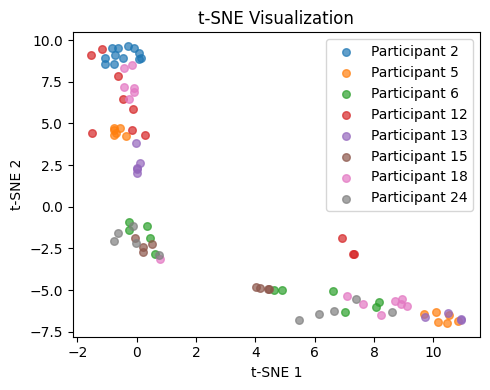

2026-02-09 00:10:49,401 - mocap - INFO - Test set size for rank classification: 87
2026-02-09 00:10:49,402 - mocap - INFO - Starting cross-validated model evaluation...
2026-02-09 00:10:49,403 - mocap - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:10:49,404 - mocap - INFO - -------------------------------------------------------
2026-02-09 00:10:49,426 - mocap - INFO - k-NN eucl    | 0.5856     | 0.7693     | 0.9196
2026-02-09 00:10:49,446 - mocap - INFO - k-NN manh    | 0.5974     | 0.8157     | 0.9536
2026-02-09 00:10:49,483 - mocap - INFO - SVM          | 0.3105     | 0.6549     | 0.8850
2026-02-09 00:10:50,739 - mocap - INFO - MLP          | 0.5752     | 0.8379     | 0.9765
2026-02-09 00:10:50,766 - mocap - INFO - NB           | 0.4575     | 0.7118     | 0.8850
2026-02-09 00:10:50,820 - mocap - INFO - LR           | 0.4144     | 0.6660     | 0.8373
2026-02-09 00:10:51,468 - mocap - INFO - RF           | 0.6209     | 0.8150     | 0.9412
2026-02-09 00:10:5

In [4]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = mocap_cycles, 
    coordinates_idx = CoordinatesIdx(2, 0, 1), 
    log_level = logging.INFO,
    logger_name = 'mocap',
    involve_hands_parameters = False,
)

cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "lstm",
    learning_rate = tpp.tp_lstm.learning_rate,
    batch_size = tpp.tp_lstm.batch_size,
    n_epochs = tpp.tp_lstm.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:10:55,360 - yolo - INFO - Preparing cycles and participant labels...
2026-02-09 00:11:07,553 - yolo - INFO - [Iteration 1/4]
2026-02-09 00:11:07,555 - yolo - INFO - [Iteration 2/4]
2026-02-09 00:11:07,584 - yolo - INFO - Train dataset size: 3126
2026-02-09 00:11:07,586 - yolo - INFO - Using device: cuda
2026-02-09 00:11:08,183 - yolo - INFO - Epoch 1, Train Loss: 5.585023624556405
2026-02-09 00:11:08,731 - yolo - INFO - Epoch 2, Train Loss: 3.8223578346018887
2026-02-09 00:11:09,480 - yolo - INFO - Epoch 3, Train Loss: 2.65138001466284
2026-02-09 00:11:10,016 - yolo - INFO - Epoch 4, Train Loss: 1.8574653103643535
2026-02-09 00:11:10,554 - yolo - INFO - Epoch 5, Train Loss: 1.3229038636295163
2026-02-09 00:11:11,115 - yolo - INFO - Epoch 6, Train Loss: 0.9526194273209085
2026-02-09 00:11:11,654 - yolo - INFO - Epoch 7, Train Loss: 0.6951961298378146
2026-02-09 00:11:12,183 - yolo - INFO - Epoch 8, Train Loss: 0.511224587961119
2026-02-09 00:11:12,755 - yolo - INFO - Epoch

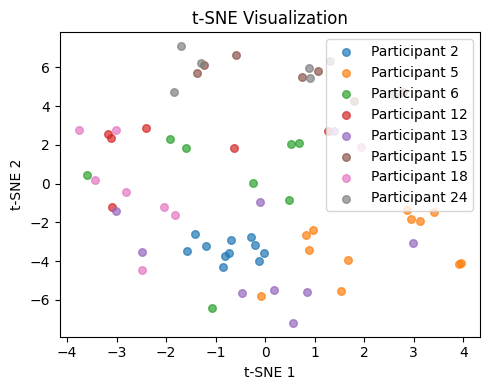

2026-02-09 00:12:11,366 - yolo - INFO - Test set size for rank classification: 68
2026-02-09 00:12:11,367 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-09 00:12:11,368 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:12:11,368 - yolo - INFO - -------------------------------------------------------
2026-02-09 00:12:11,399 - yolo - INFO - k-NN eucl    | 0.3813     | 0.7066     | 0.7670
2026-02-09 00:12:11,421 - yolo - INFO - k-NN manh    | 0.4538     | 0.7220     | 0.7648
2026-02-09 00:12:11,459 - yolo - INFO - SVM          | 0.5154     | 0.6901     | 0.7802
2026-02-09 00:12:12,544 - yolo - INFO - MLP          | 0.5593     | 0.7352     | 0.7923
2026-02-09 00:12:12,565 - yolo - INFO - NB           | 0.4549     | 0.7912     | 0.8527
2026-02-09 00:12:12,604 - yolo - INFO - LR           | 0.5451     | 0.7802     | 0.8967
2026-02-09 00:12:13,206 - yolo - INFO - RF           | 0.5725     | 0.8516     | 0.9110
2026-02-09 00:12:16,828 - yol

In [5]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_cycles, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.INFO,
    logger_name = 'yolo',
    involve_hands_parameters = False,
)
cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "conv1d",
    learning_rate = tpp.tp_conv1d.learning_rate,
    batch_size = tpp.tp_conv1d.batch_size,
    n_epochs = tpp.tp_conv1d.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:12:16,867 - yolo - INFO - Preparing cycles and participant labels...
2026-02-09 00:12:28,658 - yolo - INFO - [Iteration 1/4]
2026-02-09 00:12:28,659 - yolo - INFO - [Iteration 2/4]
2026-02-09 00:12:28,688 - yolo - INFO - Train dataset size: 3126
2026-02-09 00:12:28,689 - yolo - INFO - Using device: cuda
2026-02-09 00:12:29,415 - yolo - INFO - Epoch 1, Train Loss: 0.3208716040363117
2026-02-09 00:12:30,064 - yolo - INFO - Epoch 2, Train Loss: 0.3023690818523874
2026-02-09 00:12:30,704 - yolo - INFO - Epoch 3, Train Loss: 0.2906727171978172
2026-02-09 00:12:31,359 - yolo - INFO - Epoch 4, Train Loss: 0.27534099653059124
2026-02-09 00:12:32,250 - yolo - INFO - Epoch 5, Train Loss: 0.2595116076420765
2026-02-09 00:12:32,912 - yolo - INFO - Epoch 6, Train Loss: 0.24468850450856344
2026-02-09 00:12:33,561 - yolo - INFO - Epoch 7, Train Loss: 0.2284424043431574
2026-02-09 00:12:34,205 - yolo - INFO - Epoch 8, Train Loss: 0.21853639307070752
2026-02-09 00:12:34,860 - yolo - INFO 

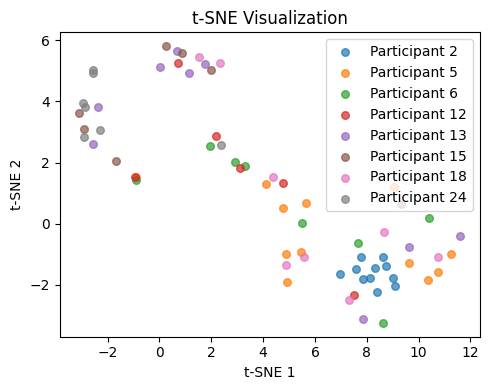

2026-02-09 00:14:09,009 - yolo - INFO - Test set size for rank classification: 68
2026-02-09 00:14:09,010 - yolo - INFO - Starting cross-validated model evaluation...
2026-02-09 00:14:09,011 - yolo - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:14:09,012 - yolo - INFO - -------------------------------------------------------
2026-02-09 00:14:09,033 - yolo - INFO - k-NN eucl    | 0.3527     | 0.5308     | 0.6330
2026-02-09 00:14:09,054 - yolo - INFO - k-NN manh    | 0.3527     | 0.4857     | 0.6033
2026-02-09 00:14:09,087 - yolo - INFO - SVM          | 0.2791     | 0.4857     | 0.6187
2026-02-09 00:14:10,294 - yolo - INFO - MLP          | 0.2791     | 0.4560     | 0.5868
2026-02-09 00:14:10,317 - yolo - INFO - NB           | 0.3418     | 0.5473     | 0.7538
2026-02-09 00:14:10,359 - yolo - INFO - LR           | 0.3374     | 0.5451     | 0.6901
2026-02-09 00:14:11,006 - yolo - INFO - RF           | 0.3385     | 0.5604     | 0.6769
2026-02-09 00:14:14,560 - yol

In [6]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_cycles, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.INFO,
    logger_name = 'yolo',
    involve_hands_parameters = False,
)

cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "lstm",
    learning_rate = tpp.tp_lstm.learning_rate,
    batch_size = tpp.tp_lstm.batch_size,
    n_epochs = tpp.tp_lstm.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:14:14,592 - yolo_best_cameras - INFO - Preparing cycles and participant labels...
2026-02-09 00:14:27,276 - yolo_best_cameras - INFO - [Iteration 1/4]
2026-02-09 00:14:27,277 - yolo_best_cameras - INFO - [Iteration 2/4]
2026-02-09 00:14:27,313 - yolo_best_cameras - INFO - Train dataset size: 3416
2026-02-09 00:14:27,314 - yolo_best_cameras - INFO - Using device: cuda
2026-02-09 00:14:28,122 - yolo_best_cameras - INFO - Epoch 1, Train Loss: 8.317425471599972
2026-02-09 00:14:28,937 - yolo_best_cameras - INFO - Epoch 2, Train Loss: 5.505470933201157
2026-02-09 00:14:29,748 - yolo_best_cameras - INFO - Epoch 3, Train Loss: 3.6733315470062684
2026-02-09 00:14:30,551 - yolo_best_cameras - INFO - Epoch 4, Train Loss: 2.5053175437116177
2026-02-09 00:14:31,341 - yolo_best_cameras - INFO - Epoch 5, Train Loss: 1.7394480816671782
2026-02-09 00:14:32,197 - yolo_best_cameras - INFO - Epoch 6, Train Loss: 1.246289432327324
2026-02-09 00:14:33,010 - yolo_best_cameras - INFO - Epoch 7,

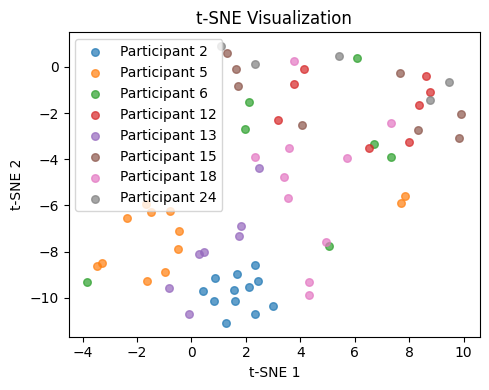

2026-02-09 00:15:38,655 - yolo_best_cameras - INFO - Test set size for rank classification: 69
2026-02-09 00:15:38,656 - yolo_best_cameras - INFO - Starting cross-validated model evaluation...
2026-02-09 00:15:38,656 - yolo_best_cameras - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:15:38,657 - yolo_best_cameras - INFO - -------------------------------------------------------
2026-02-09 00:15:38,678 - yolo_best_cameras - INFO - k-NN eucl    | 0.5945     | 0.7549     | 0.8264
2026-02-09 00:15:38,699 - yolo_best_cameras - INFO - k-NN manh    | 0.5956     | 0.7407     | 0.7978
2026-02-09 00:15:38,734 - yolo_best_cameras - INFO - SVM          | 0.5495     | 0.6648     | 0.7527
2026-02-09 00:15:39,647 - yolo_best_cameras - INFO - MLP          | 0.6527     | 0.8549     | 0.8989
2026-02-09 00:15:39,669 - yolo_best_cameras - INFO - NB           | 0.5505     | 0.7088     | 0.7835
2026-02-09 00:15:39,711 - yolo_best_cameras - INFO - LR           | 0.6099     | 0.8110 

In [7]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_best_cams_cycles, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_best_cameras',
    involve_hands_parameters = False,
)
cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "conv1d",
    learning_rate = tpp.tp_conv1d.learning_rate,
    batch_size = tpp.tp_conv1d.batch_size,
    n_epochs = tpp.tp_conv1d.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:15:44,015 - yolo_best_cameras - INFO - Preparing cycles and participant labels...
2026-02-09 00:15:56,491 - yolo_best_cameras - INFO - [Iteration 1/4]
2026-02-09 00:15:56,492 - yolo_best_cameras - INFO - [Iteration 2/4]
2026-02-09 00:15:56,524 - yolo_best_cameras - INFO - Train dataset size: 3416
2026-02-09 00:15:56,525 - yolo_best_cameras - INFO - Using device: cuda
2026-02-09 00:15:57,240 - yolo_best_cameras - INFO - Epoch 1, Train Loss: 0.35831513791997854
2026-02-09 00:15:57,946 - yolo_best_cameras - INFO - Epoch 2, Train Loss: 0.3497624388922041
2026-02-09 00:15:58,657 - yolo_best_cameras - INFO - Epoch 3, Train Loss: 0.3383142719759005
2026-02-09 00:15:59,372 - yolo_best_cameras - INFO - Epoch 4, Train Loss: 0.32662312533253823
2026-02-09 00:16:00,100 - yolo_best_cameras - INFO - Epoch 5, Train Loss: 0.3112239918419134
2026-02-09 00:16:00,807 - yolo_best_cameras - INFO - Epoch 6, Train Loss: 0.2962571693079494
2026-02-09 00:16:01,515 - yolo_best_cameras - INFO - Epo

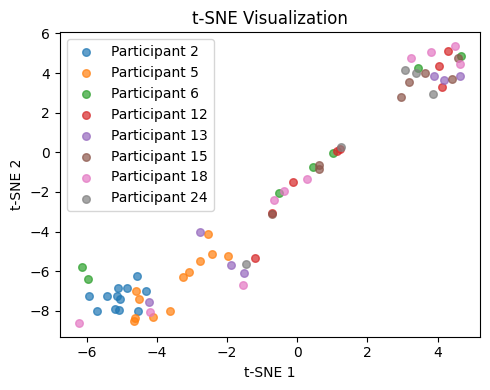

2026-02-09 00:17:46,580 - yolo_best_cameras - INFO - Test set size for rank classification: 69
2026-02-09 00:17:46,581 - yolo_best_cameras - INFO - Starting cross-validated model evaluation...
2026-02-09 00:17:46,581 - yolo_best_cameras - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:17:46,582 - yolo_best_cameras - INFO - -------------------------------------------------------
2026-02-09 00:17:46,604 - yolo_best_cameras - INFO - k-NN eucl    | 0.3626     | 0.5209     | 0.6516
2026-02-09 00:17:46,624 - yolo_best_cameras - INFO - k-NN manh    | 0.3495     | 0.5077     | 0.6385
2026-02-09 00:17:46,658 - yolo_best_cameras - INFO - SVM          | 0.3165     | 0.5352     | 0.6088
2026-02-09 00:17:47,886 - yolo_best_cameras - INFO - MLP          | 0.3352     | 0.6088     | 0.7681
2026-02-09 00:17:47,915 - yolo_best_cameras - INFO - NB           | 0.3187     | 0.5077     | 0.6802
2026-02-09 00:17:47,958 - yolo_best_cameras - INFO - LR           | 0.3626     | 0.4934 

In [8]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_best_cams_cycles, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_best_cameras',
    involve_hands_parameters = False,
)

cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "lstm",
    learning_rate = tpp.tp_lstm.learning_rate,
    batch_size = tpp.tp_lstm.batch_size,
    n_epochs = tpp.tp_lstm.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:17:52,320 - yolo_butterworth - INFO - Preparing cycles and participant labels...
2026-02-09 00:18:03,424 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-09 00:18:03,425 - yolo_butterworth - INFO - [Iteration 2/4]
2026-02-09 00:18:03,450 - yolo_butterworth - INFO - Train dataset size: 2634
2026-02-09 00:18:03,451 - yolo_butterworth - INFO - Using device: cuda
2026-02-09 00:18:04,105 - yolo_butterworth - INFO - Epoch 1, Train Loss: 3.1542874775737166
2026-02-09 00:18:04,740 - yolo_butterworth - INFO - Epoch 2, Train Loss: 1.6869892578527153
2026-02-09 00:18:05,340 - yolo_butterworth - INFO - Epoch 3, Train Loss: 0.9118429397244051
2026-02-09 00:18:05,975 - yolo_butterworth - INFO - Epoch 4, Train Loss: 0.5406354439545826
2026-02-09 00:18:06,606 - yolo_butterworth - INFO - Epoch 5, Train Loss: 0.3701886270778725
2026-02-09 00:18:07,223 - yolo_butterworth - INFO - Epoch 6, Train Loss: 0.28694435433450954
2026-02-09 00:18:07,850 - yolo_butterworth - INFO - Epoch 7, Train L

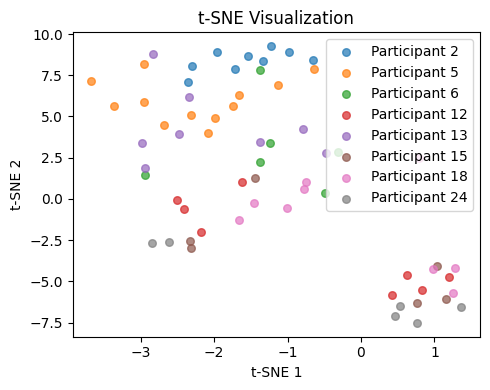

2026-02-09 00:19:00,373 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-09 00:19:00,375 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-09 00:19:00,375 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:19:00,376 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-09 00:19:00,399 - yolo_butterworth - INFO - k-NN eucl    | 0.4692     | 0.7038     | 0.8449
2026-02-09 00:19:00,419 - yolo_butterworth - INFO - k-NN manh    | 0.4538     | 0.6885     | 0.8449
2026-02-09 00:19:00,457 - yolo_butterworth - INFO - SVM          | 0.4705     | 0.7833     | 0.8923
2026-02-09 00:19:01,670 - yolo_butterworth - INFO - MLP          | 0.5769     | 0.7346     | 0.8436
2026-02-09 00:19:01,692 - yolo_butterworth - INFO - NB           | 0.5167     | 0.7962     | 0.8910
2026-02-09 00:19:01,735 - yolo_butterworth - INFO - LR           | 0.5462     | 0.8295     | 0.89

In [9]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_cycles_butterworth, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_butterworth',
    involve_hands_parameters = False,
)
cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "conv1d",
    learning_rate = tpp.tp_conv1d.learning_rate,
    batch_size = tpp.tp_conv1d.batch_size,
    n_epochs = tpp.tp_conv1d.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:19:05,915 - yolo_butterworth - INFO - Preparing cycles and participant labels...
2026-02-09 00:19:16,883 - yolo_butterworth - INFO - [Iteration 1/4]
2026-02-09 00:19:16,885 - yolo_butterworth - INFO - [Iteration 2/4]
2026-02-09 00:19:16,909 - yolo_butterworth - INFO - Train dataset size: 2634
2026-02-09 00:19:16,911 - yolo_butterworth - INFO - Using device: cuda
2026-02-09 00:19:17,510 - yolo_butterworth - INFO - Epoch 1, Train Loss: 0.3502975533525628
2026-02-09 00:19:18,067 - yolo_butterworth - INFO - Epoch 2, Train Loss: 0.3389760821339596
2026-02-09 00:19:18,609 - yolo_butterworth - INFO - Epoch 3, Train Loss: 0.3189081714813968
2026-02-09 00:19:19,162 - yolo_butterworth - INFO - Epoch 4, Train Loss: 0.3056014593107155
2026-02-09 00:19:19,709 - yolo_butterworth - INFO - Epoch 5, Train Loss: 0.2942133303507265
2026-02-09 00:19:20,262 - yolo_butterworth - INFO - Epoch 6, Train Loss: 0.2752520643084882
2026-02-09 00:19:20,811 - yolo_butterworth - INFO - Epoch 7, Train Lo

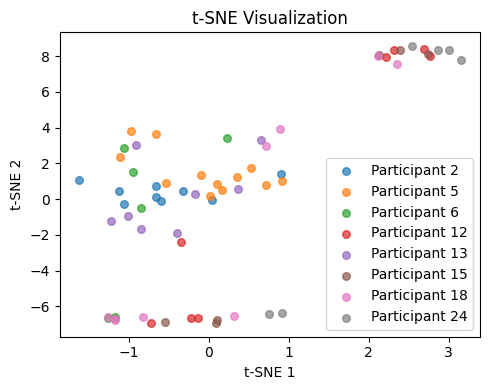

2026-02-09 00:20:40,914 - yolo_butterworth - INFO - Test set size for rank classification: 64
2026-02-09 00:20:40,915 - yolo_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-09 00:20:40,916 - yolo_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:20:40,916 - yolo_butterworth - INFO - -------------------------------------------------------
2026-02-09 00:20:40,937 - yolo_butterworth - INFO - k-NN eucl    | 0.3923     | 0.5487     | 0.7538
2026-02-09 00:20:40,957 - yolo_butterworth - INFO - k-NN manh    | 0.4244     | 0.5641     | 0.7692
2026-02-09 00:20:40,991 - yolo_butterworth - INFO - SVM          | 0.2346     | 0.5615     | 0.8295
2026-02-09 00:20:42,171 - yolo_butterworth - INFO - MLP          | 0.4410     | 0.6590     | 0.7679
2026-02-09 00:20:42,194 - yolo_butterworth - INFO - NB           | 0.3615     | 0.5641     | 0.8141
2026-02-09 00:20:42,239 - yolo_butterworth - INFO - LR           | 0.3128     | 0.5949     | 0.87

In [10]:
cv = CrossValidationSiameseRaw(
    sequence_cycles=yolo_cycles_butterworth, 
    coordinates_idx=CoordinatesIdx(0, 1, 2), 
    log_level=logging.INFO,
    logger_name = 'yolo_butterworth',
    involve_hands_parameters = False,
)

cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "lstm",
    learning_rate = tpp.tp_lstm.learning_rate,
    batch_size = tpp.tp_lstm.batch_size,
    n_epochs = tpp.tp_lstm.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:20:46,556 - yolo_best_cameras_butterworth - INFO - Preparing cycles and participant labels...
2026-02-09 00:20:58,051 - yolo_best_cameras_butterworth - INFO - [Iteration 1/4]
2026-02-09 00:20:58,052 - yolo_best_cameras_butterworth - INFO - [Iteration 2/4]
2026-02-09 00:20:58,079 - yolo_best_cameras_butterworth - INFO - Train dataset size: 2650
2026-02-09 00:20:58,080 - yolo_best_cameras_butterworth - INFO - Using device: cuda
2026-02-09 00:20:58,714 - yolo_best_cameras_butterworth - INFO - Epoch 1, Train Loss: 4.159060535660709
2026-02-09 00:20:59,339 - yolo_best_cameras_butterworth - INFO - Epoch 2, Train Loss: 2.4225926743932518
2026-02-09 00:20:59,962 - yolo_best_cameras_butterworth - INFO - Epoch 3, Train Loss: 1.4087714376937912
2026-02-09 00:21:00,595 - yolo_best_cameras_butterworth - INFO - Epoch 4, Train Loss: 0.8421863547290664
2026-02-09 00:21:01,228 - yolo_best_cameras_butterworth - INFO - Epoch 5, Train Loss: 0.5391277652907084
2026-02-09 00:21:01,855 - yolo_b

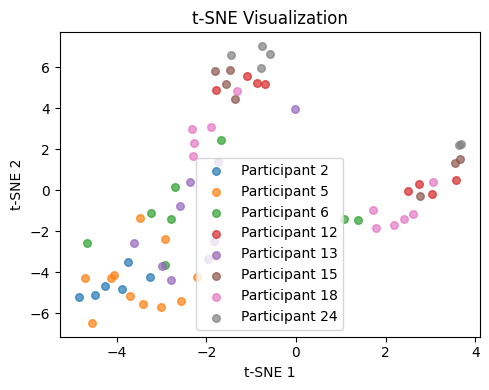

2026-02-09 00:21:55,799 - yolo_best_cameras_butterworth - INFO - Test set size for rank classification: 67
2026-02-09 00:21:55,800 - yolo_best_cameras_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-09 00:21:55,801 - yolo_best_cameras_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:21:55,801 - yolo_best_cameras_butterworth - INFO - -------------------------------------------------------
2026-02-09 00:21:55,823 - yolo_best_cameras_butterworth - INFO - k-NN eucl    | 0.4769     | 0.7022     | 0.8505
2026-02-09 00:21:55,843 - yolo_best_cameras_butterworth - INFO - k-NN manh    | 0.4780     | 0.7187     | 0.8945
2026-02-09 00:21:55,876 - yolo_best_cameras_butterworth - INFO - SVM          | 0.4934     | 0.7473     | 0.9407
2026-02-09 00:21:57,072 - yolo_best_cameras_butterworth - INFO - MLP          | 0.5077     | 0.7615     | 0.8824
2026-02-09 00:21:57,092 - yolo_best_cameras_butterworth - INFO - NB           | 0.4626     | 

In [11]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_best_cams_cycles_butterworth, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.INFO,
    logger_name = 'yolo_best_cameras_butterworth',
    involve_hands_parameters = False,
)
cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "conv1d",
    learning_rate = tpp.tp_conv1d.learning_rate,
    batch_size = tpp.tp_conv1d.batch_size,
    n_epochs = tpp.tp_conv1d.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)

2026-02-09 00:22:01,491 - yolo_best_cameras_butterworth - INFO - Preparing cycles and participant labels...
2026-02-09 00:22:12,855 - yolo_best_cameras_butterworth - INFO - [Iteration 1/4]
2026-02-09 00:22:12,857 - yolo_best_cameras_butterworth - INFO - [Iteration 2/4]
2026-02-09 00:22:12,883 - yolo_best_cameras_butterworth - INFO - Train dataset size: 2650
2026-02-09 00:22:12,884 - yolo_best_cameras_butterworth - INFO - Using device: cuda
2026-02-09 00:22:13,491 - yolo_best_cameras_butterworth - INFO - Epoch 1, Train Loss: 0.3312740816050265
2026-02-09 00:22:14,085 - yolo_best_cameras_butterworth - INFO - Epoch 2, Train Loss: 0.31358070509979524
2026-02-09 00:22:14,663 - yolo_best_cameras_butterworth - INFO - Epoch 3, Train Loss: 0.30234967782554856
2026-02-09 00:22:15,241 - yolo_best_cameras_butterworth - INFO - Epoch 4, Train Loss: 0.28109902951372673
2026-02-09 00:22:15,816 - yolo_best_cameras_butterworth - INFO - Epoch 5, Train Loss: 0.26792426389383983
2026-02-09 00:22:16,381 - y

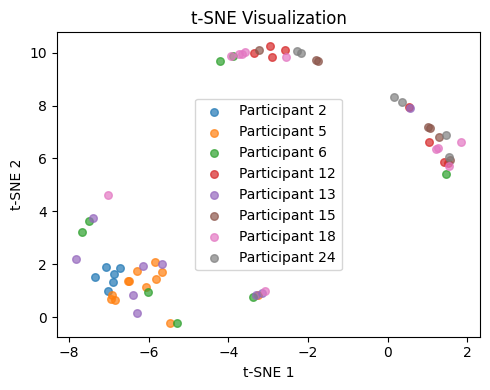

2026-02-09 00:23:36,785 - yolo_best_cameras_butterworth - INFO - Test set size for rank classification: 67
2026-02-09 00:23:36,785 - yolo_best_cameras_butterworth - INFO - Starting cross-validated model evaluation...
2026-02-09 00:23:36,786 - yolo_best_cameras_butterworth - INFO - Model        | Rank-1     | Rank-2     | Rank-3    
2026-02-09 00:23:36,786 - yolo_best_cameras_butterworth - INFO - -------------------------------------------------------
2026-02-09 00:23:36,809 - yolo_best_cameras_butterworth - INFO - k-NN eucl    | 0.2670     | 0.5088     | 0.7769
2026-02-09 00:23:36,830 - yolo_best_cameras_butterworth - INFO - k-NN manh    | 0.2989     | 0.5385     | 0.7780
2026-02-09 00:23:36,861 - yolo_best_cameras_butterworth - INFO - SVM          | 0.2868     | 0.4648     | 0.7187
2026-02-09 00:23:37,976 - yolo_best_cameras_butterworth - INFO - MLP          | 0.4165     | 0.6110     | 0.8066
2026-02-09 00:23:37,997 - yolo_best_cameras_butterworth - INFO - NB           | 0.3451     | 

In [12]:
cv = CrossValidationSiameseRaw(
    sequence_cycles = yolo_best_cams_cycles_butterworth, 
    coordinates_idx = CoordinatesIdx(0, 1, 2), 
    log_level = logging.INFO,
    logger_name = 'yolo_best_cameras_butterworth',
    involve_hands_parameters = False,
)

cv.perform_training_with_rank_classification(
    n_folds = tpp.n_folds,
    siamese_nn_type = "lstm",
    learning_rate = tpp.tp_lstm.learning_rate,
    batch_size = tpp.tp_lstm.batch_size,
    n_epochs = tpp.tp_lstm.n_epochs,
    embedding_size = 10,
    tsne_perplexity = 20,
    show_plot = True, 
)